## VinDr ChestXRay

Análise exploratória dos arquivos `annotations_train.csv` e `annotations_test.csv`.

In [44]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')

In [45]:
base_path = Path('data/vindrxray')
train_path = base_path / 'annotations_train.csv'
test_path = base_path / 'annotations_test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

train_df['split'] = 'train'
test_df['split'] = 'test'
all_df = pd.concat([train_df, test_df], ignore_index=True)

display(train_df.head())
display(test_df.head())


,image_id,rad_ID,class_name,x_min,y_min,x_max,y_max,class_id,split
0,03d56a9709a81b2e9d6afbc6647c8730,R3,Boot-shaped heart,378.760010,401.416645,835.143248,661.678438,0,train
1,48f7ba0b0fd5ab847ee87df2aed5cfc9,R3,Peribronchovascular interstitial opacity,247.196368,412.000819,441.763442,830.320028,1,train
2,48f7ba0b0fd5ab847ee87df2aed5cfc9,R3,Peribronchovascular interstitial opacity,613.631024,364.980443,902.238850,827.077243,1,train
3,74f8648d742bbcce79d67c967de5552d,R3,Peribronchovascular interstitial opacity,1008.515903,665.439667,1324.430364,1265.465119,1,train
4,74f8648d742bbcce79d67c967de5552d,R3,Peribronchovascular interstitial opacity,453.015307,635.756429,724.404911,1242.142575,1,train


,image_id,rad_ID,class_name,x_min,y_min,x_max,y_max,class_id,split
0,754319622ab33ef050acc93f3abb30c9,R3,Reticulonodular opacity,261.815256,423.207990,503.876077,736.463170,2,test
1,754319622ab33ef050acc93f3abb30c9,R3,Peribronchovascular interstitial opacity,708.559859,396.510105,927.482514,756.041619,1,test
2,06d3af071602023190578f5c957498c3,R3,Peribronchovascular interstitial opacity,608.657762,258.905311,850.583057,688.823511,1,test
3,06d3af071602023190578f5c957498c3,R3,Peribronchovascular interstitial opacity,184.903264,255.823461,380.600796,685.741660,1,test
4,e52a0ff39ea6942d1860a4e619cb8518,R3,Peribronchovascular interstitial opacity,325.547761,492.778816,572.221416,708.227958,1,test


In [46]:
def summarize_split(df, split_name):
    label_by_image = df[['image_id', 'class_name']].drop_duplicates()
    no_finding_images = label_by_image[label_by_image['class_name'] == 'No finding']['image_id'].nunique()
    return pd.Series({
        'split': split_name,
        'rows': len(df),
        'images': df['image_id'].nunique(),
        'radiologists': df['rad_ID'].nunique(),
        'classes': df['class_name'].nunique(),
        'images_with_no_finding': no_finding_images,
    })

summary_df = pd.DataFrame([
    summarize_split(train_df, 'train'),
    summarize_split(test_df, 'test'),
    summarize_split(all_df, 'train + test'),
])

summary_df


,split,rows,images,radiologists,classes,images_with_no_finding
0,train,10371,7728,6,37,5143
1,test,1850,1397,6,24,907
2,train + test,12221,9125,6,37,6050


In [47]:
annotation_counts = (all_df.groupby(['split', 'class_name'])
    .size()
    .reset_index(name='annotation_count'))

image_counts = (all_df[['split', 'image_id', 'class_name']]
    .drop_duplicates()
    .groupby(['split', 'class_name'])
    .size()
    .reset_index(name='image_count'))

train_image_labels = image_counts[image_counts['split'] == 'train'].sort_values('image_count', ascending=False)
test_image_labels = image_counts[image_counts['split'] == 'test'].sort_values('image_count', ascending=False)

display(train_image_labels.head(15))
display(test_image_labels.head(15))


,split,class_name,image_count
49,train,No finding,5143
54,train,Peribronchovascular interstitial opacity,1358
29,train,Bronchial thickening,562
59,train,Reticulonodular opacity,509
34,train,Consolidation,176
31,train,Cardiomegaly,161
52,train,Other opacity,148
36,train,Diffuse aveolar opacity,119
47,train,Lung hyperinflation,108
50,train,Other lesion,65


,split,class_name,image_count
16,test,No finding,907
20,test,Peribronchovascular interstitial opacity,248
3,test,Bronchial thickening,116
22,test,Reticulonodular opacity,90
6,test,Consolidation,35
4,test,Cardiomegaly,29
19,test,Other opacity,27
8,test,Diffuse aveolar opacity,21
15,test,Lung hyperinflation,21
10,test,Enlarged PA,11


/tmp/ipykernel_58254/850136934.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='annotation_count', y='class_name', ax=ax, palette='Blues_r')
/tmp/ipykernel_58254/850136934.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='annotation_count', y='class_name', ax=ax, palette='Blues_r')


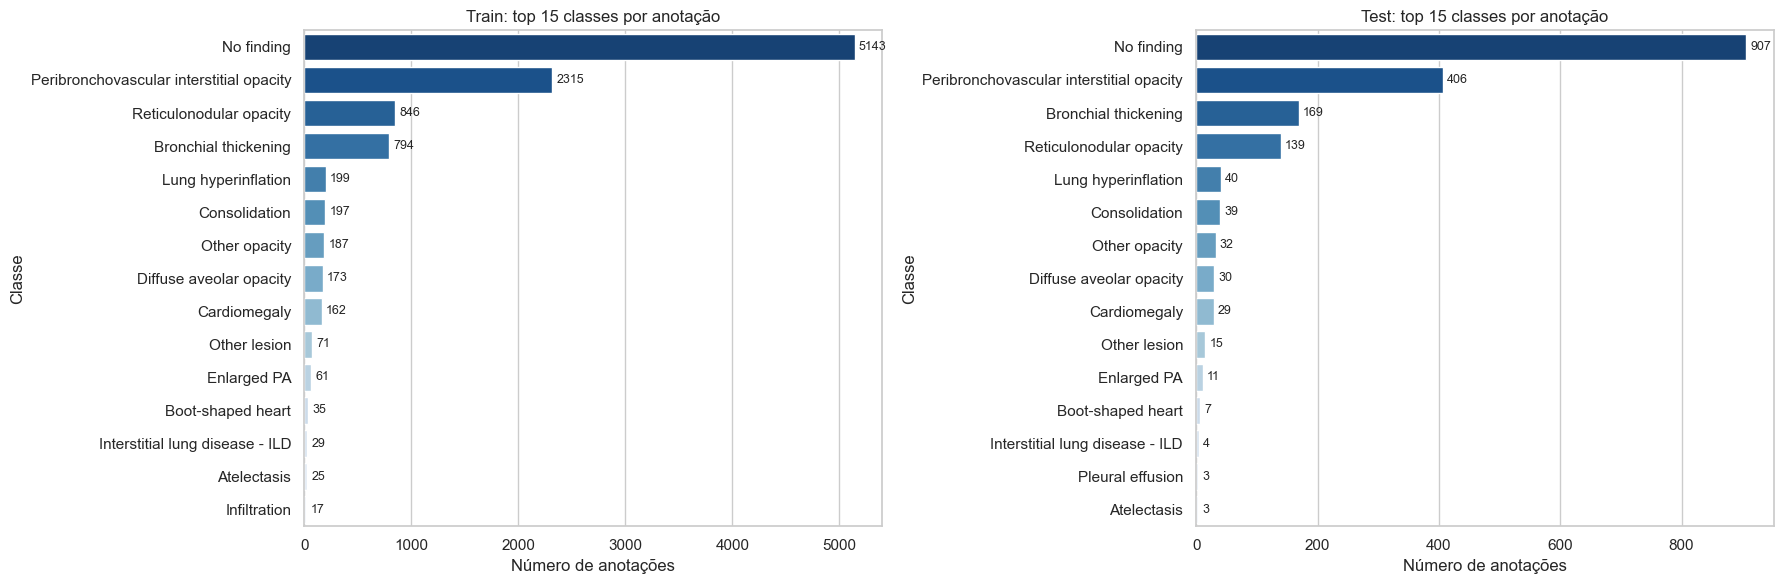

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

for ax, split_name in zip(axes, ['train', 'test']):
    plot_df = (annotation_counts[annotation_counts['split'] == split_name]
        .sort_values('annotation_count', ascending=False)
        .head(15))
    sns.barplot(data=plot_df, x='annotation_count', y='class_name', ax=ax, palette='Blues_r')
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3, fontsize=9)
    ax.set_title(f'{split_name.capitalize()}: top 15 classes por anotação')
    ax.set_xlabel('Número de anotações')
    ax.set_ylabel('Classe')

plt.tight_layout()
plt.show()


/tmp/ipykernel_58254/604486560.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='image_count', y='class_name', ax=ax, palette='Greens_r')
/tmp/ipykernel_58254/604486560.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='image_count', y='class_name', ax=ax, palette='Greens_r')


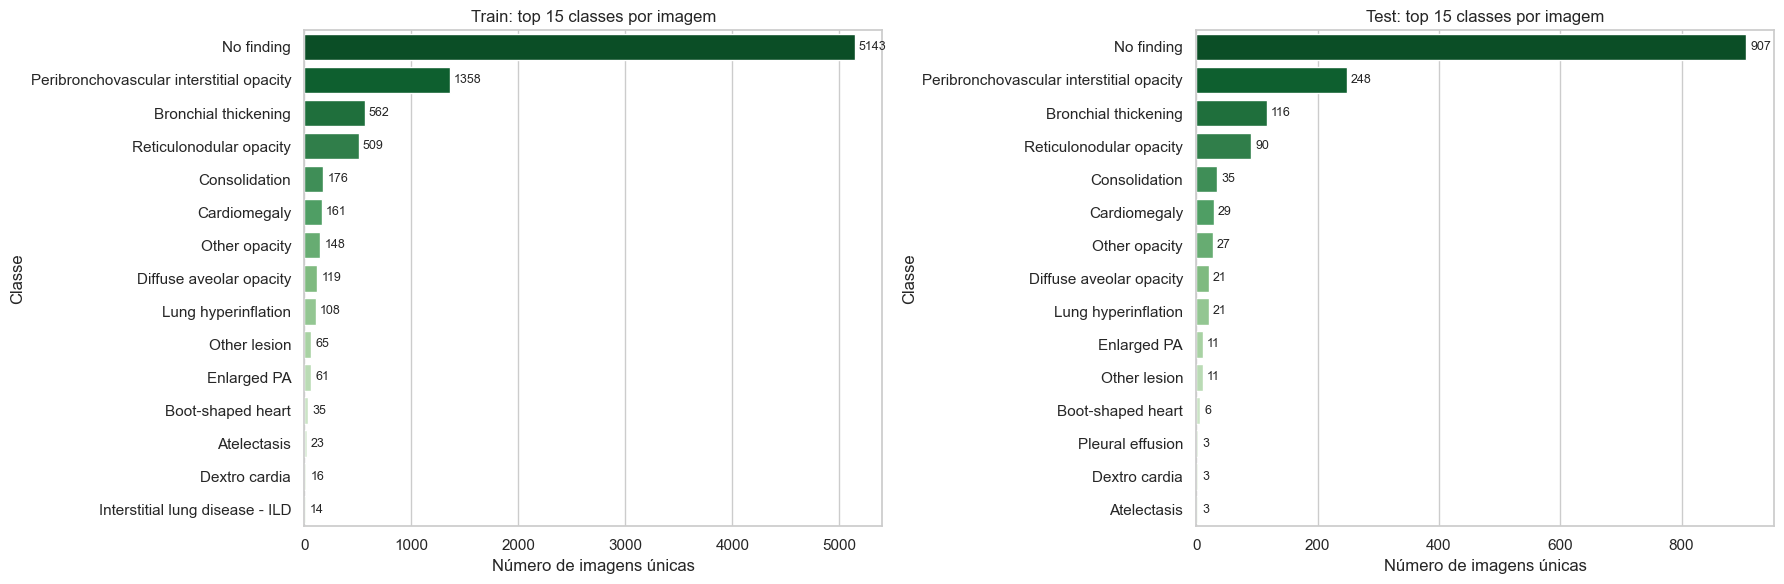

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

for ax, split_name in zip(axes, ['train', 'test']):
    plot_df = (image_counts[image_counts['split'] == split_name]
        .sort_values('image_count', ascending=False)
        .head(15))
    sns.barplot(data=plot_df, x='image_count', y='class_name', ax=ax, palette='Greens_r')
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3, fontsize=9)
    ax.set_title(f'{split_name.capitalize()}: top 15 classes por imagem')
    ax.set_xlabel('Número de imagens únicas')
    ax.set_ylabel('Classe')

plt.tight_layout()
plt.show()


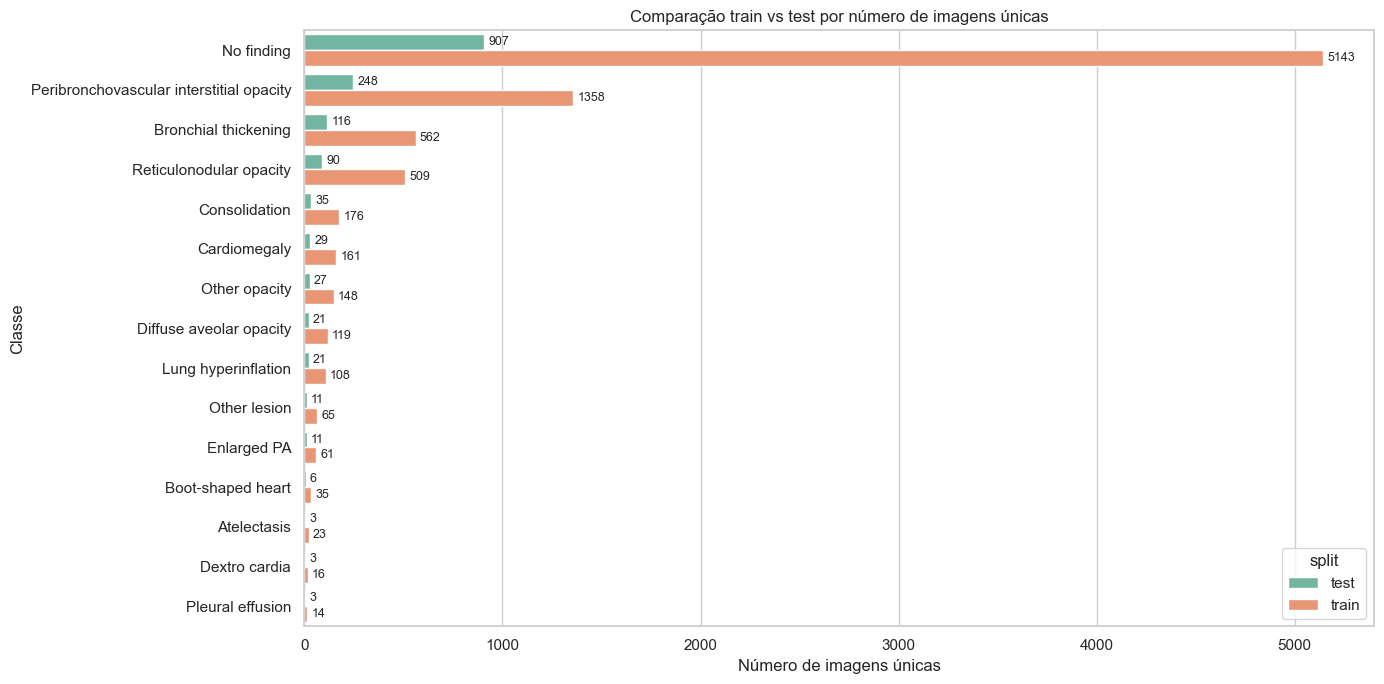

split,class_name,test,train
0,No finding,907,5143
1,Peribronchovascular interstitial opacity,248,1358
2,Bronchial thickening,116,562
3,Reticulonodular opacity,90,509
4,Consolidation,35,176
5,Cardiomegaly,29,161
6,Other opacity,27,148
7,Diffuse aveolar opacity,21,119
8,Lung hyperinflation,21,108
9,Other lesion,11,65


In [50]:
comparison_df = (image_counts.pivot(index='class_name', columns='split', values='image_count')
    .fillna(0)
    .astype(int))
comparison_df['total'] = comparison_df.sum(axis=1)
comparison_df = comparison_df.sort_values('total', ascending=False).head(15).drop(columns='total').reset_index()

comparison_long = comparison_df.melt(id_vars='class_name', var_name='split', value_name='image_count')

plt.figure(figsize=(14, 7))
ax = sns.barplot(data=comparison_long, x='image_count', y='class_name', hue='split', palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=9)
plt.title('Comparação train vs test por número de imagens únicas')
plt.xlabel('Número de imagens únicas')
plt.ylabel('Classe')
plt.tight_layout()
plt.show()

comparison_df
